# Lab 3: Clustering Using K-Means and K-Medoids

**Name:** Anusha Pittala  
**Course:** MSCS-634 Advanced Big Data and Data Mining  
**Assignment:** Lab 3 - Clustering Using K-Means and K-Medoids

## Objective

The purpose of this lab is to explore and compare K-Means and K-Medoids clustering techniques using the Wine Dataset from the sklearn library. The dataset will be standardized before clustering. The performance of both algorithms will be evaluated using the Silhouette Score and Adjusted Rand Index (ARI), followed by visualization and comparison of the resulting clusters.

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

### Environment Setup

The `scikit-learn-extra` package is used to implement the K-Medoids algorithm. The environment variables above were set to avoid Windows-specific threading warnings when running the clustering algorithms.

In [2]:
!pip install scikit-learn-extra

## Step 1: Load and Prepare the Dataset

In [3]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

from sklearn_extra.cluster import KMedoids

In [4]:
# Load the Wine dataset
wine = load_wine()

# Extract features and target labels
X = wine.data
y = wine.target

# Create a DataFrame for easier exploration
df = pd.DataFrame(X, columns=wine.feature_names)

# Add the actual class labels
df['target'] = y

# Display the first five rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Basic Data Exploration

In [5]:
# Display dataset dimensions
print("Dataset shape:", df.shape)

# Display feature names
print("\nFeature Names:")
print(wine.feature_names)

# Display target class names
print("\nTarget Classes:")
print(wine.target_names)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset shape: (178, 14)

Feature Names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Target Classes:
['class_0' 'class_1' 'class_2']

Missing Values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


In [6]:
# Display the distribution of actual Wine classes
class_distribution = df['target'].value_counts().sort_index()

print("Class Distribution:")
print(class_distribution)

Class Distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


### Observation

The Wine dataset contains 178 samples belonging to three different wine classes. Class 0 contains 59 samples, Class 1 contains 71 samples, and Class 2 contains 48 samples. The classes are reasonably balanced, although Class 1 has slightly more observations than the other two classes.

### Data Standardization

In [7]:
# Separate features from the target variable
X = df.drop('target', axis=1)
y = df['target']

# Standardize the features using z-score normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original feature shape:", X.shape)
print("Standardized feature shape:", X_scaled.shape)

Original feature shape: (178, 13)
Standardized feature shape: (178, 13)


In [8]:
# Check the mean and standard deviation after standardization
print("Mean of standardized features:")
print(np.round(X_scaled.mean(axis=0), 2))

print("\nStandard deviation of standardized features:")
print(np.round(X_scaled.std(axis=0), 2))

Mean of standardized features:
[ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]

Standard deviation of standardized features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Observation

Z-score standardization transforms the features so that they have approximately zero mean and unit variance. This step is important because clustering algorithms rely on distance calculations, and Wine dataset features have different measurement scales. Standardization prevents features with larger numerical values from dominating the clustering process.

## Step 2: Implement K-Means Clustering

In [9]:
# Create and train the K-Means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit the model and obtain cluster labels
kmeans_labels = kmeans.fit_predict(X_scaled)

# Display the cluster labels
print("K-Means Cluster Labels:")
print(kmeans_labels)

K-Means Cluster Labels:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [10]:
# Calculate K-Means evaluation metrics

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("K-Means Silhouette Score:", round(kmeans_silhouette, 4))
print("K-Means Adjusted Rand Index (ARI):", round(kmeans_ari, 4))

K-Means Silhouette Score: 0.2849
K-Means Adjusted Rand Index (ARI): 0.8975


### K-Means Observation

The K-Means clustering model was created using three clusters because the Wine dataset contains three known classes. The Silhouette Score measures how well separated the generated clusters are, while the Adjusted Rand Index (ARI) measures the similarity between the predicted clusters and the actual wine classes.

The K-Means model produced a moderate Silhouette Score, indicating that the clusters have some overlap but still show meaningful separation. The high ARI value indicates that the K-Means clusters correspond closely to the actual class labels in the Wine dataset.

In [11]:
# Display number of samples assigned to each K-Means cluster
unique, counts = np.unique(kmeans_labels, return_counts=True)

print("K-Means Cluster Distribution:")
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} samples")

K-Means Cluster Distribution:
Cluster 0: 65 samples
Cluster 1: 51 samples
Cluster 2: 62 samples


## Step 3: Implement K-Medoids Clustering

In [12]:
# Create and train the K-Medoids model with 3 clusters
kmedoids = KMedoids(
    n_clusters=3,
    random_state=42,
    metric='euclidean'
)

# Fit the model and obtain cluster labels
kmedoids_labels = kmedoids.fit_predict(X_scaled)

# Display cluster labels
print("K-Medoids Cluster Labels:")
print(kmedoids_labels)

K-Medoids Cluster Labels:
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 2 1 2 1 1 1 2 1 2 1 2
 2 1 1 1 1 2 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 2 0 1 2 1 1 1 1 1 1 1 1 1 1 2 2
 1 1 1 1 1 1 1 1 1 2 2 0 1 2 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [13]:
# Calculate K-Medoids evaluation metrics

kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("K-Medoids Silhouette Score:", round(kmedoids_silhouette, 4))
print("K-Medoids Adjusted Rand Index (ARI):", round(kmedoids_ari, 4))

K-Medoids Silhouette Score: 0.266
K-Medoids Adjusted Rand Index (ARI): 0.7263


In [14]:
# Display number of samples assigned to each K-Medoids cluster
unique, counts = np.unique(kmedoids_labels, return_counts=True)

print("K-Medoids Cluster Distribution:")
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} samples")

K-Medoids Cluster Distribution:
Cluster 0: 51 samples
Cluster 1: 54 samples
Cluster 2: 73 samples


### K-Medoids Observation

The K-Medoids algorithm was also implemented with three clusters. Unlike K-Means, which represents each cluster using the mean of its points, K-Medoids selects actual observations from the dataset as cluster centers.

The Silhouette Score indicates how well separated the K-Medoids clusters are, while the Adjusted Rand Index (ARI) shows how closely the generated clusters correspond to the actual wine classes. These results will be compared with the K-Means results to determine which clustering method performs better on the standardized Wine dataset.

## Step 4: Visualize and Compare Results

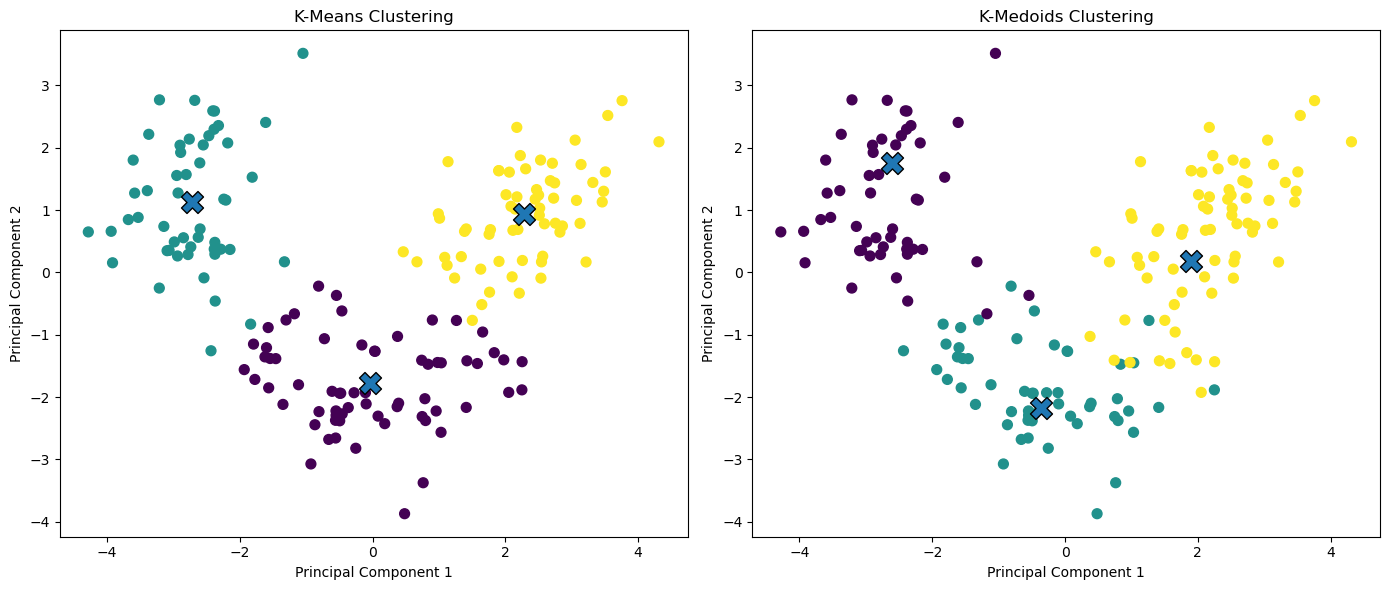

In [15]:
# Reduce the standardized data to two dimensions using PCA for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Transform K-Means centroids into PCA space
kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)

# Get K-Medoids centers and transform them into PCA space
kmedoids_centers_pca = pca.transform(kmedoids.cluster_centers_)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means plot
axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    s=50
)

axes[0].scatter(
    kmeans_centers_pca[:, 0],
    kmeans_centers_pca[:, 1],
    marker='X',
    s=250,
    edgecolor='black'
)

axes[0].set_title("K-Means Clustering")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

# K-Medoids plot
axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmedoids_labels,
    s=50
)

axes[1].scatter(
    kmedoids_centers_pca[:, 0],
    kmedoids_centers_pca[:, 1],
    marker='X',
    s=250,
    edgecolor='black'
)

axes[1].set_title("K-Medoids Clustering")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

### Comparison of K-Means and K-Medoids

The K-Means algorithm achieved a Silhouette Score of 0.2849 and an Adjusted Rand Index (ARI) of 0.8975. In comparison, the K-Medoids algorithm achieved a Silhouette Score of 0.2660 and an ARI of 0.7263.

Based on both evaluation metrics, K-Means performed better on the Wine dataset. The higher Silhouette Score indicates that the K-Means clusters were slightly more compact and better separated. The higher ARI also shows that the K-Means cluster assignments corresponded more closely to the actual Wine class labels.

The visualizations show that both algorithms identify similar broad groupings, but some observations are assigned differently near the cluster boundaries. K-Means uses calculated centroids, while K-Medoids uses actual data points as cluster centers.

K-Means is generally preferable when the dataset is numeric, reasonably clean, and not strongly affected by outliers. K-Medoids can be preferable when the dataset contains outliers or when using actual observations as cluster representatives is important, because medoids are generally more robust to extreme values.

## Conclusion

In this lab, K-Means and K-Medoids clustering were applied to the standardized Wine dataset using three clusters. Both algorithms were evaluated using the Silhouette Score and Adjusted Rand Index. K-Means achieved better results than K-Medoids on both metrics, indicating stronger cluster separation and greater similarity to the actual class structure. The experiment also demonstrated the importance of feature standardization and visualization when evaluating clustering algorithms.